# 04 — Phase Folding: Stacking the Transits, and Testing Whether We Really Saw Them

**Hack4Dev Iraq 2026 · Exoplanet Data Challenge · Track F**
Team: Mostafa & Sara

Notebook 03 built an AI model using **injected** transits. This notebook asks the other question:

> Can we see the **real** transits in this data at all?

The idea is to stack every night of the same planet on top of each other to beat down the noise —
and then, crucially, to **test the result against control stars** before believing it.

## First: why the standard Kepler/TESS pipeline does not apply here

The usual professional pipeline is: **BLS period search → phase folding → global + local views → CNN**.
That is the right method for Kepler and TESS. It does not fit this dataset, and it is worth showing exactly why.

| Step | Works here? | Why |
|---|---|---|
| **BLS period search** | No | BLS looks for *repeating* dips. We have 1–6 short windows per star, separated by many unobserved orbits. TrES-5: 6 transits spread across 12 elapsed orbits. The period cannot be recovered from our data. |
| **"Global view"** (whole orbit) | No | We only observed 3–13% of each orbit (Step 2 measures this), all of it near phase 0. A global view would be ~90% empty. |
| **Phase folding** | **Yes, partly** | Using the *published* period (not one we discovered), we can stack the transit windows. TrES-5 gives 5–6 transits → noise improves by about √5 ≈ 2.2. |
| **CNN on global/local views** | No | AstroNet was trained on ~15,000 labelled Kepler signals. We have 8 stars and 22 nights, all of the same class. |
| **U-shape vs V-shape** (eclipsing binaries) | No | Our noise is 1.1–2.5% per point and the transits are 1.6–2.75% deep, so the signal-to-noise per point is about 1. Shape cannot be resolved, and we have no eclipsing-binary labels. |

So this notebook keeps the one step that *does* work — phase folding — and adds the control test that the
professional pipelines also rely on.

In [1]:
# Step 1: setup
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

warnings.filterwarnings("ignore")
OUTPUT_DIR = Path("..") / "outputs"

lc = pd.read_csv(OUTPUT_DIR / "light_curves.csv")          # produced by notebook 02
params = pd.read_csv(OUTPUT_DIR / "planet_parameters.csv")  # produced by notebook 03
quality = pd.read_csv(OUTPUT_DIR / "photometry_quality.csv")

planets = {"CoRoT-2": "CoRoT-2 b", "HATP-10": "WASP-11 b", "Qatar-1": "Qatar-1 b", "TRES-1": "TrES-1 b",
           "TRES-3": "TrES-3 b", "TRES-5": "TrES-5 b", "WASP-10": "WASP-10 b", "WASP-2": "WASP-2 b"}
site = EarthLocation(lat=31.68 * u.deg, lon=-110.88 * u.deg, height=1268 * u.m)

# only nights where our photometry was reasonable
usable = quality[quality["median_scatter_%"] < 3]
good_nights = set(zip(usable.target, usable.night))
print("nights with scatter below 3%:", len(good_nights))

nights with scatter below 3%: 11


## Step 2 — How much of each orbit did we actually observe?

Before folding, we measure our phase coverage. This is the number that rules BLS out.

In [2]:
# Step 2: orbital phase coverage per target
def phase_of(g, p):
    """Orbital phase of each measurement: 0 = middle of transit, +/-0.5 = opposite side of the orbit."""
    times = Time(g.time_ut.tolist(), format="isot", scale="utc", location=site)
    bjd = (times.tdb + times.light_travel_time(SkyCoord(p.ra * u.deg, p.dec * u.deg), "barycentric")).jd
    return ((bjd - p.pl_tranmid) / p.pl_orbper + 0.5) % 1 - 0.5

coverage = []
for target, g_target in lc.groupby("target"):
    p = params[params.pl_name == planets[target]].iloc[0]
    phases = np.concatenate([phase_of(g, p) for _, g in g_target.groupby("night")])
    coverage.append({"target": target,
                     "nights": g_target.night.nunique(),
                     "period_days": round(p.pl_orbper, 3),
                     "phase_covered_%": len(set(np.floor(phases * 100).astype(int))),
                     "phase_min": round(float(phases.min()), 3),
                     "phase_max": round(float(phases.max()), 3)})
pd.DataFrame(coverage).sort_values("nights", ascending=False)

,target,nights,period_days,phase_covered_%,phase_min,phase_max
4,TRES-5,6,1.482,12,-0.052,0.051
3,TRES-3,4,1.306,13,-0.052,0.070
0,CoRoT-2,3,1.743,12,-0.041,0.062
2,Qatar-1,2,1.420,12,-0.054,0.054
6,WASP-2,2,2.152,8,-0.007,0.067
1,HATP-10,1,3.722,7,-0.020,0.030
5,WASP-10,1,3.093,3,-0.018,0.005


## Step 3 — Fold and stack the planet host

The planet host is the star the telescope pointed at, so it is the star closest to the centre of the image.

For each night we first remove a slow trend (a straight line fitted to the **out-of-transit** points only),
then we place every measurement at its orbital phase and stack all nights together.

In [3]:
# Step 3: build a folded, stacked light curve
def night_curve(target, night, star_id, p, half_width):
    """One night of one star: phase and de-trended relative brightness."""
    g = lc[(lc.target == target) & (lc.night == night) & (lc.star_id == star_id)].sort_values("mjd")
    if len(g) < 30:
        return None
    phase = phase_of(g, p)
    flux = g.rel_flux.values
    outside = np.abs(phase) > half_width
    if outside.sum() < 10:
        return None
    trend = np.polyfit(phase[outside], flux[outside], 1)     # straight line from out-of-transit points only
    return phase, flux / np.polyval(trend, phase)

def stack(parts, half_width):
    """Combine several nights and measure the average depth inside the transit."""
    phase = np.concatenate([x[0] for x in parts])
    flux = np.concatenate([x[1] for x in parts])
    inside = np.abs(phase) < half_width
    outside = np.abs(phase) > half_width * 1.5
    if inside.sum() < 20 or outside.sum() < 20:
        return None
    depth = (np.mean(flux[outside]) - np.mean(flux[inside])) * 100
    return {"phase": phase, "flux": flux, "depth_%": depth, "n_in": int(inside.sum())}

def central_star(target, night):
    """The star nearest the image centre on that night."""
    stars = lc[(lc.target == target) & (lc.night == night)].groupby("star_id")[["star_x", "star_y"]].first()
    return np.hypot(stars.star_x - 325, stars.star_y - 250).idxmin(), stars

results = {}
for target in ["TRES-5", "CoRoT-2", "Qatar-1"]:
    p = params[params.pl_name == planets[target]].iloc[0]
    half = (p.pl_trandur / 24) / p.pl_orbper / 2
    nights = [n for n in sorted(lc[lc.target == target].night.unique()) if (target, n) in good_nights]
    parts = []
    for night in nights:
        sid, _ = central_star(target, night)
        c = night_curve(target, night, sid, p, half)
        if c:
            parts.append(c)
    if len(parts) < 2:
        print(f"{target}: only {len(parts)} usable night(s) — skipped")
        continue
    s = stack(parts, half)
    s.update(target=target, nights=len(parts), expected=p.pl_trandep, half=half)
    results[target] = s
    print(f"{target}: stacked {len(parts)} transits -> measured depth {s['depth_%']:+.2f}%  (published {p.pl_trandep:.2f}%)")

TRES-5: stacked 5 transits -> measured depth +1.11%  (published 2.19%)
CoRoT-2: stacked 2 transits -> measured depth +0.52%  (published 2.75%)
Qatar-1: stacked 2 transits -> measured depth +0.75%  (published 2.14%)


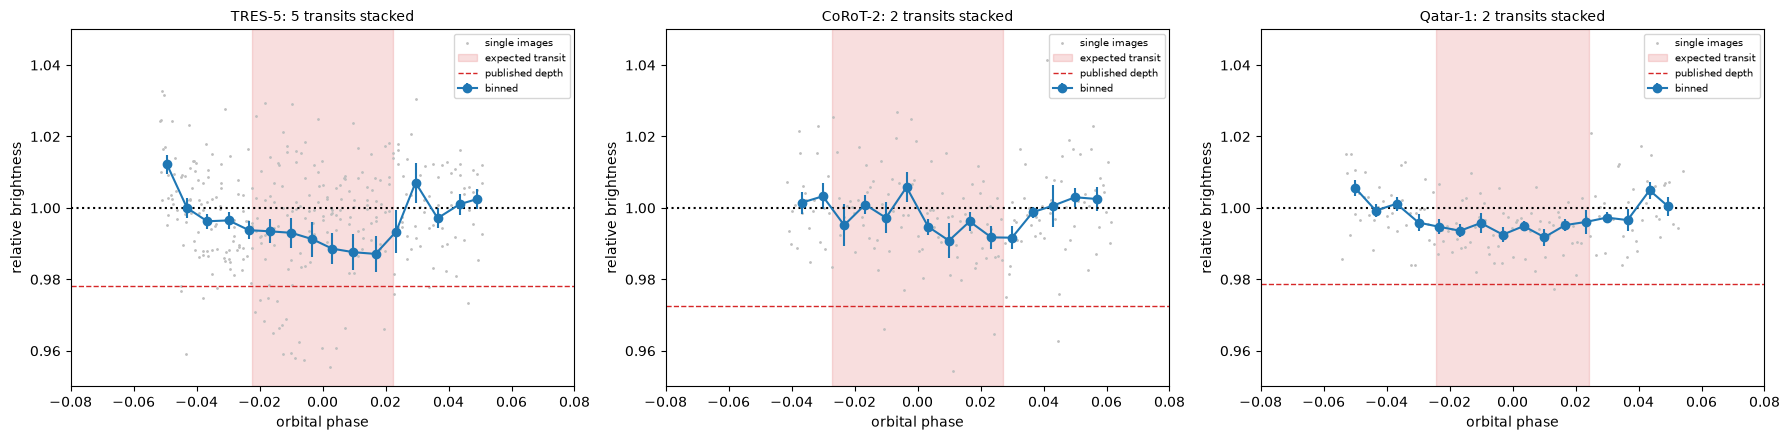

In [4]:
# Step 3b: plot the folded light curves
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4.5), squeeze=False)
for ax, (target, s) in zip(axes.flat, results.items()):
    ax.plot(s["phase"], s["flux"], ".", ms=2, color="0.75", label="single images")
    edges = np.linspace(-0.08, 0.08, 25)
    which = np.digitize(s["phase"], edges)
    bx, by, be = [], [], []
    for i in range(1, len(edges)):
        m = which == i
        if m.sum() > 3:
            bx.append(s["phase"][m].mean()); by.append(s["flux"][m].mean())
            be.append(s["flux"][m].std() / np.sqrt(m.sum()))
    ax.errorbar(bx, by, yerr=be, fmt="o-", color="tab:blue", label="binned")
    ax.axvspan(-s["half"], s["half"], color="tab:red", alpha=0.15, label="expected transit")
    ax.axhline(1, ls=":", color="k")
    ax.axhline(1 - s["expected"] / 100, ls="--", color="tab:red", lw=1, label="published depth")
    ax.set_xlim(-0.08, 0.08); ax.set_ylim(0.95, 1.05)
    ax.set_xlabel("orbital phase"); ax.set_ylabel("relative brightness")
    ax.set_title(f"{target}: {s['nights']} transits stacked", fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Step 4 — The control test (the most important cell in this notebook)

The host star shows *some* dip. But is that a transit, or does **every** star in the image dip at phase 0?

Every one of our nights was scheduled **around the transit**, so phase 0 is also the **middle of the night** —
exactly when the star is highest and the conditions are most stable. Any effect that depends on time of night
will therefore imitate a transit.

So we repeat the identical analysis on ordinary stars in the same images. They have no planets, so whatever
depth they show is our **noise floor**. A real detection must stand clearly above it.

We match the same physical star across nights by its position **relative to the central star**, because
`star_id` is only a per-night brightness ranking.

In [5]:
# Step 4: fold every other star the same way, to build a "no planet" distribution
def control_depths(target, min_nights=2):
    p = params[params.pl_name == planets[target]].iloc[0]
    half = (p.pl_trandur / 24) / p.pl_orbper / 2
    nights = [n for n in sorted(lc[lc.target == target].night.unique()) if (target, n) in good_nights]

    catalogues = {}
    for night in nights:
        sid, stars = central_star(target, night)
        stars = stars.copy()
        stars["rx"] = stars.star_x - stars.loc[sid, "star_x"]     # position relative to the host
        stars["ry"] = stars.star_y - stars.loc[sid, "star_y"]
        catalogues[night] = (stars, sid)

    master, master_centre = catalogues[nights[0]]
    depths = []
    for star_id, row in master.iterrows():
        if star_id == master_centre:
            continue
        parts = []
        for night in nights:
            stars, _ = catalogues[night]
            distance = np.hypot(stars.rx - row.rx, stars.ry - row.ry)
            if distance.min() > 5:          # the same physical star was not measured this night
                continue
            c = night_curve(target, night, distance.idxmin(), p, half)
            if c:
                parts.append(c)
        if len(parts) >= min_nights:
            s = stack(parts, half)
            if s:
                depths.append(s["depth_%"])
    return np.array(depths)

verdict = []
for target, s in results.items():
    controls = control_depths(target)
    if len(controls) < 3:
        print(f"{target}: only {len(controls)} control stars matched — cannot test")
        continue
    deeper = int((controls > s["depth_%"]).sum())
    verdict.append({"target": target,
                    "host_depth_%": round(s["depth_%"], 2),
                    "published_depth_%": s["expected"],
                    "controls": len(controls),
                    "control_mean_%": round(float(controls.mean()), 2),
                    "control_std_%": round(float(controls.std()), 2),
                    "controls_deeper": deeper,
                    "controls_deeper_%": round(100 * deeper / len(controls)),
                    "z_score": round(float((s["depth_%"] - controls.mean()) / controls.std()), 1)})
pd.DataFrame(verdict)

Qatar-1: only 0 control stars matched — cannot test


,target,host_depth_%,published_depth_%,controls,control_mean_%,control_std_%,controls_deeper,controls_deeper_%,z_score
0,TRES-5,1.11,2.192,31,0.82,1.01,16,52,0.3
1,CoRoT-2,0.52,2.750,27,0.09,0.39,5,19,1.1


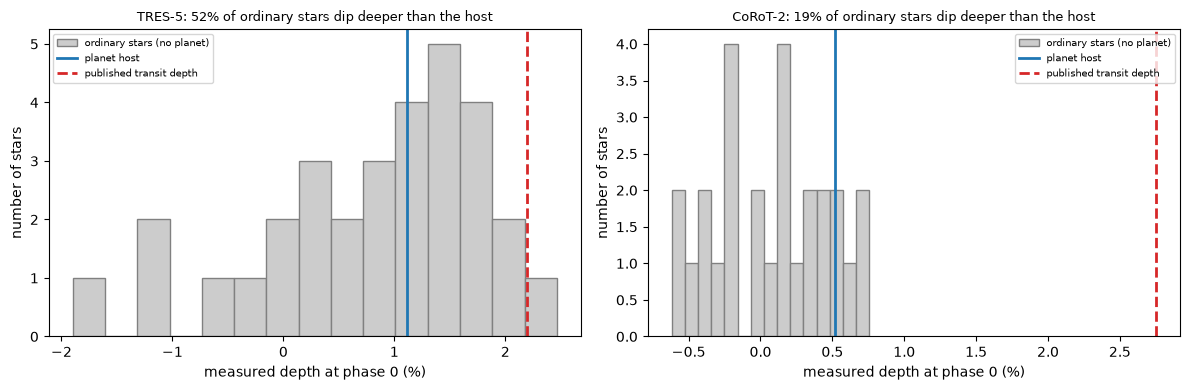

In [6]:
# Step 4b: show the host against the control distribution
fig, axes = plt.subplots(1, len(verdict), figsize=(6 * len(verdict), 4), squeeze=False)
for ax, row in zip(axes.flat, verdict):
    controls = control_depths(row["target"])
    ax.hist(controls, bins=15, color="0.8", edgecolor="0.5", label="ordinary stars (no planet)")
    ax.axvline(row["host_depth_%"], color="tab:blue", lw=2, label="planet host")
    ax.axvline(row["published_depth_%"], color="tab:red", ls="--", lw=2, label="published transit depth")
    ax.set_xlabel("measured depth at phase 0 (%)")
    ax.set_ylabel("number of stars")
    ax.set_title(f"{row['target']}: {row['controls_deeper_%']}% of ordinary stars dip deeper than the host", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Step 5 — What we conclude

Read the table and the histograms before reading this text, then compare.

**The honest conclusion: we did not detect the transits.**

- The host star's folded depth is *smaller* than the published depth, and
- ordinary stars with no planets show dips of the same size at the same phase.

For TrES-5 the formal error bar on the host suggests a confident measurement, but the spread **between stars**
is several times larger than that error bar. That difference is the whole lesson: the formal error only describes
random noise, while the control stars reveal the systematic error, which is what actually limits us.

**Why this happens:** our per-point precision is about 1.1–2.5%, the transits are 1.6–2.75% deep, and every night
is centred on the transit, so any effect that varies through the night imitates a dip at phase 0.

**What would be needed for a real detection:** more nights per planet (to average the systematics down), observations
that extend well before and after the transit so the baseline is not itself centred on the event, and comparison
stars matched in brightness and colour to the host.

**This is a result, not a failure.** We tested our own claim and it did not survive — which is exactly what the
control test is for. Reporting it is worth more than a detection we cannot defend.

## Try it yourself

1. In Step 1 change the quality cut from `< 3` to `< 2`. Fewer, better nights — does the host depth get closer to the published value, or does it just get noisier?
2. In Step 4 change `min_nights` to 3. How many control stars survive, and does the conclusion change?
3. Fold a target using a **wrong** period (multiply `pl_orbper` by 1.05) and re-run Step 3. What does the folded curve look like when the period is wrong? This shows why a period search needs continuous coverage.